# Import Library & Set Globals

In [2]:
%load_ext jupyter_black

# base
import warnings
import logging
from pathlib import Path

# data manipulation
import re
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# single cell
import scanpy as sc
import decoupler as dc
import gseapy as gp

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix


In [3]:
%matplotlib inline
study = "paper_processed_FULL"

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

In [4]:
annotation = "annotated"
savedir = DATADIR / "processed" / "single cell" / "5_analysis"
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

# TGFb & IFN genes

In [5]:
def sort_cytokines_gsea(df, queries):
    query_pattern = "|".join(queries)
    filtered = df[df.Term.str.contains(query_pattern, case=False, regex=True)].copy()

    # Detect query type based on patterns
    query_str = " ".join(queries).lower()

    if re.search(r"il\d+|interleukin", query_str):
        # Interleukin sorting
        filtered["sort_key"] = filtered.Term.str.extract(
            r"(?:il|interleukin)[_\s]*(\d+)", flags=re.IGNORECASE
        )[0].astype(float)
    elif "interferon" in query_str or "ifn" in query_str:
        # Interferon sorting
        def get_ifn_sort_key(term):
            term = term.lower()
            if re.search(r"type_i[^i]|type\s+i[^i]", term):
                return (1, "alpha")
            elif "alpha" in term:
                return (1, "alpha")
            elif re.search(r"type_ii|type\s+ii", term):
                return (2, "gamma")
            elif "beta" in term:
                return (1, "beta")
            elif "gamma" in term:
                return (2, "gamma")
            else:
                return (0, term)

        filtered["sort_key"] = filtered.Term.apply(get_ifn_sort_key)
    else:
        # Default sorting (alphabetical)
        filtered["sort_key"] = filtered.Term

    return filtered.sort_values("sort_key").drop("sort_key", axis=1)


tgfb_genes = adata.var_names[adata.var_names.str.contains("Tgfb")].to_list() + [
    "Il33",
    "Ly6a",
    "Ccl2",
    "Dpp4",  # No response
    "Smad2",
    "Smad3",
    "Smad4",
    "Serpine1",
    "Id1",
    "Id2",
    "Id3",  # Intermediate responsive
    "Fn1",
    "Postn",
    "Cthrc1",
    "Vim",
    "Col1a1",
    "Col1a2",
    "Serpinh1",  # High responsive
]

ifn_genes = adata.var_names[adata.var_names.str.contains("Ifn")].to_list() + [
    "Fasn",
    "Irs1",
    "Insr",  # Repressed
    "Irf3",
    "Irf4",
    "Ifi47",
    "Irf1",
    "Ifitm1",
    "Ifitm2",
    "Ifitm3",  # Induced
    "Isg15",
    "Cxcl9",
    "Cxcl10",
]

print(f"tgfb signals list: {len(tgfb_genes)}\nifn signals list: {len(ifn_genes)}")

tgfb signals list: 28
ifn signals list: 21


## Pan cell-type

In [ ]:
ewat_adata = adata[adata.obs["Sample Type"] == "eWAT"]
hfd_ewat = ewat_adata[ewat_adata.obs["Condition"] == "HFD"]
lfd_ewat = ewat_adata[ewat_adata.obs["Condition"] == "LFD"]

Text(0.5, 0.98, 'Cytokine-Responsive Genes in eWAT')

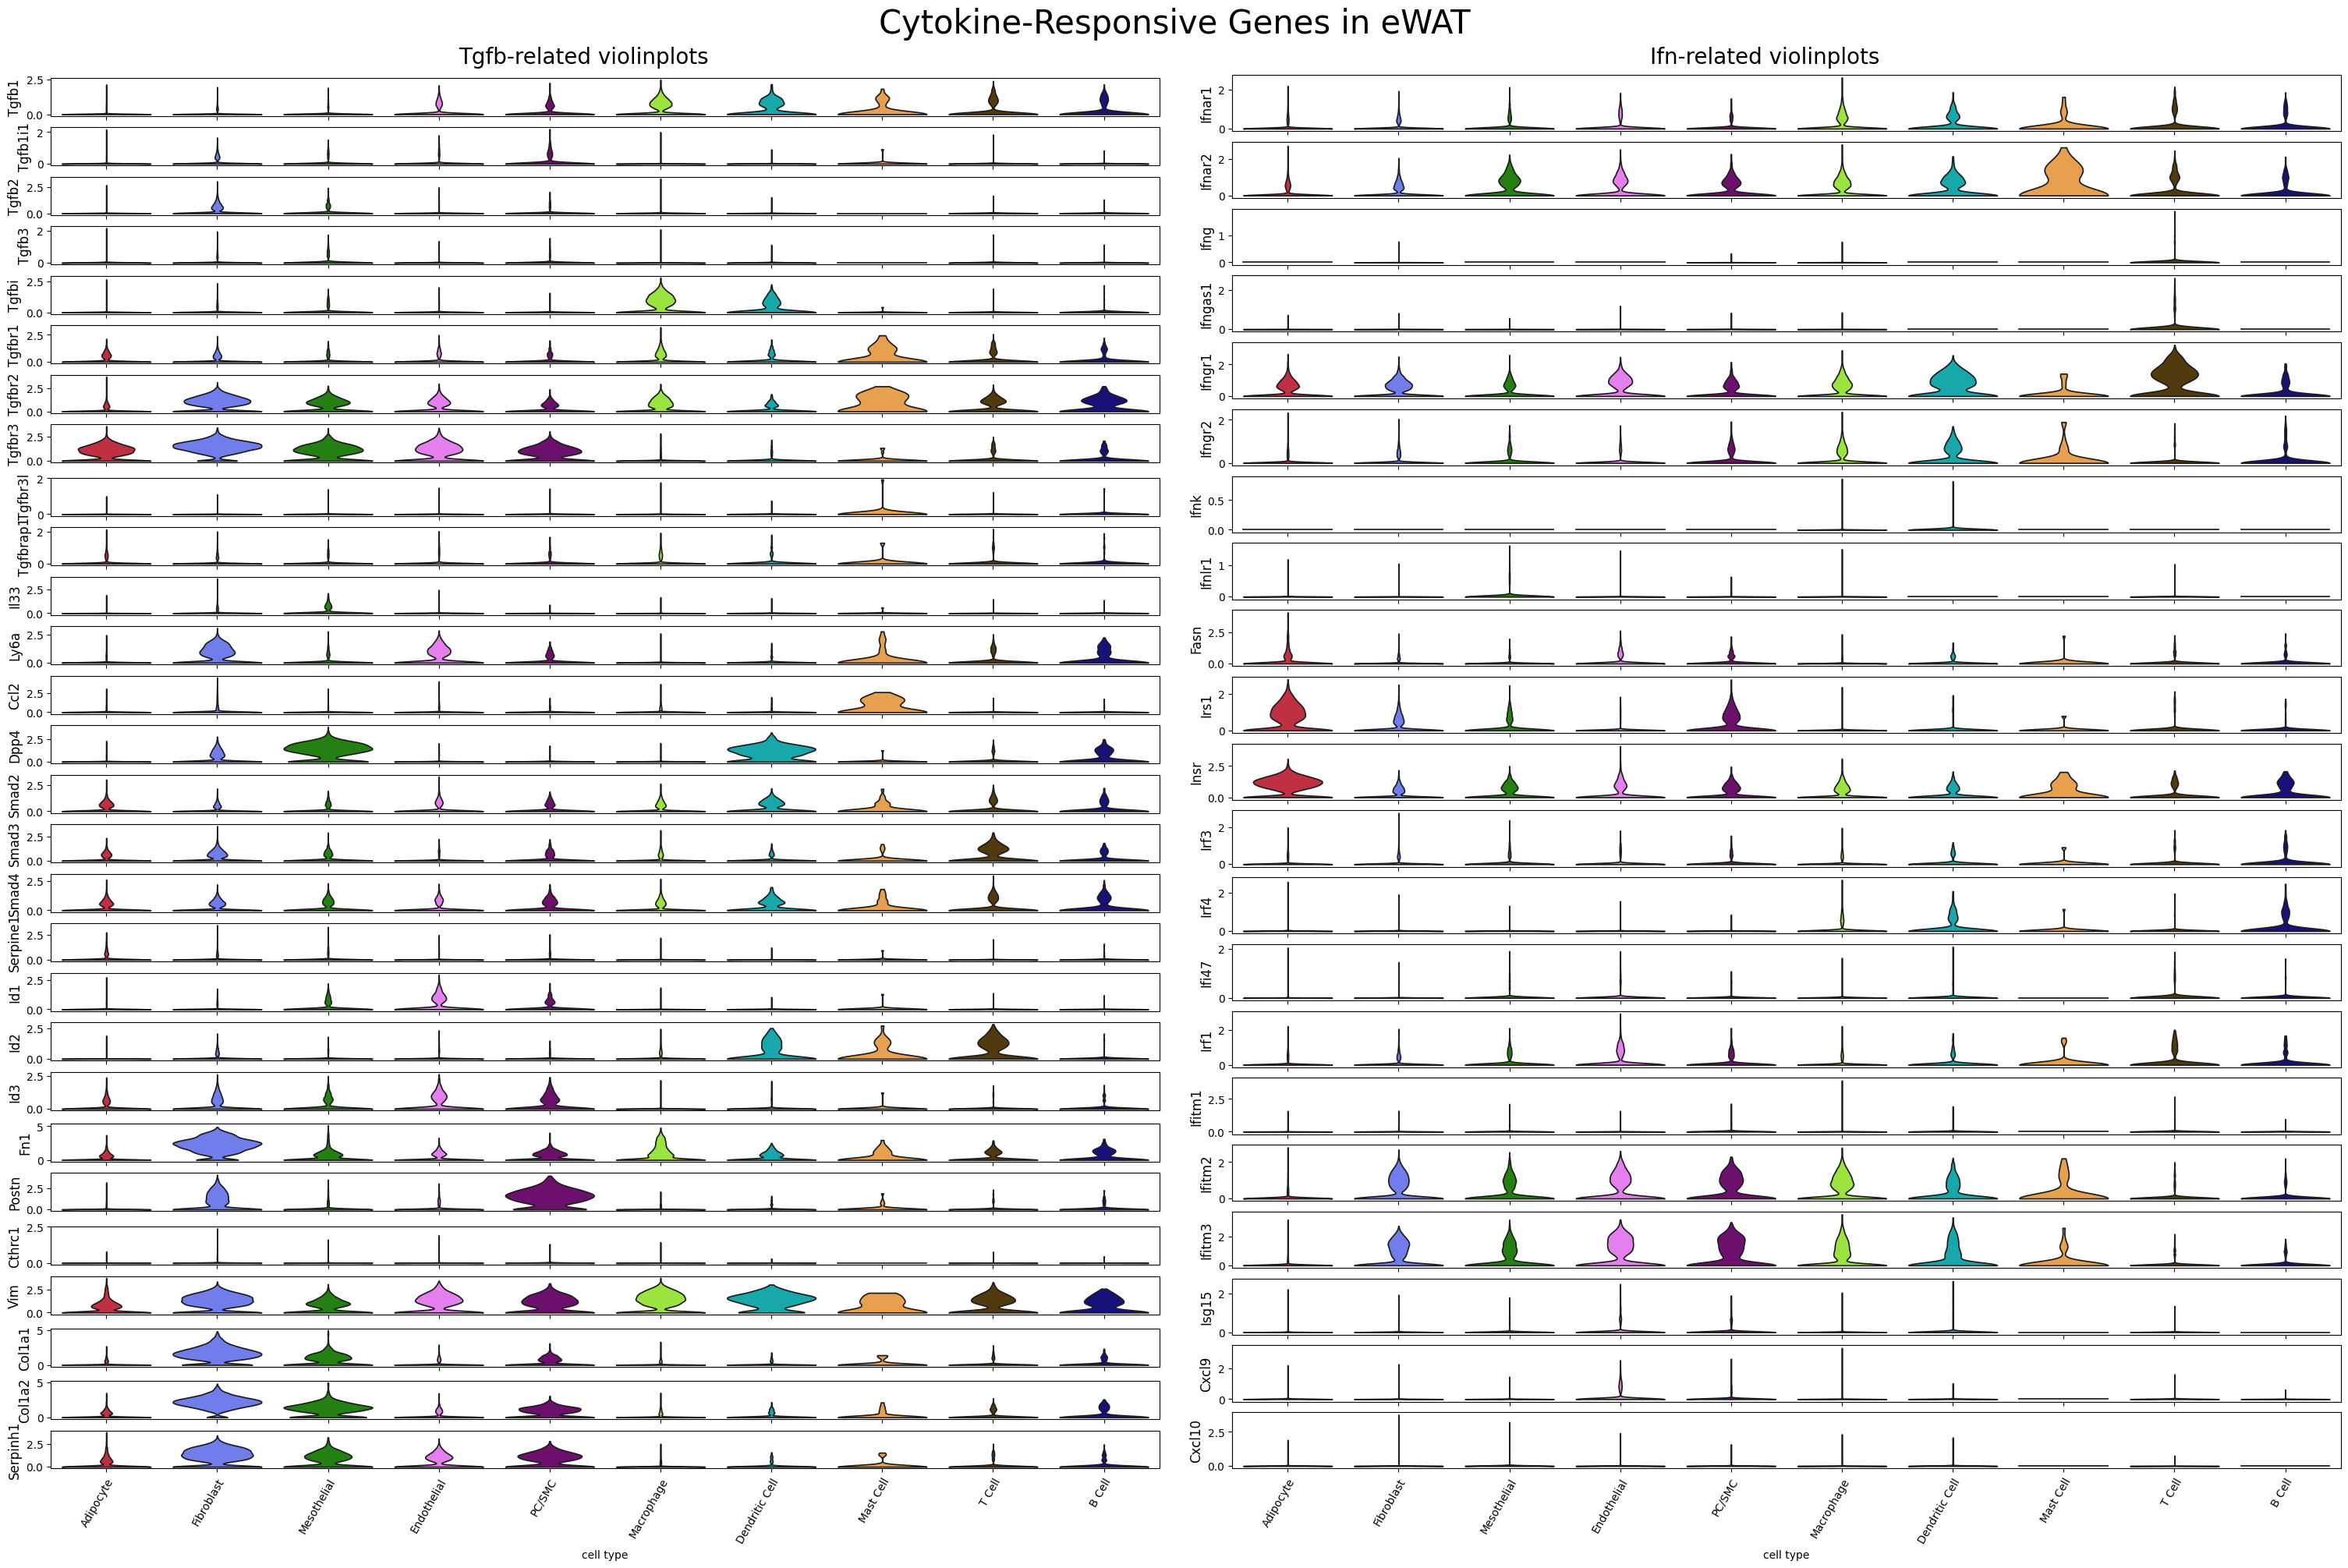

In [ ]:
f = plt.figure(figsize=(20, 30), layout="constrained")
sf = f.subfigures(1, 2)
plot_violinplot(ewat_adata, tgfb_genes, "cell_type", f=sf[0], useStripPlot=False)
sf[0].suptitle("Tgfb-related violinplots", size=20)

plot_violinplot(ewat_adata, ifn_genes, "cell_type", f=sf[1], useStripPlot=False)
sf[1].suptitle("Ifn-related violinplots", size=20)

f.suptitle("Cytokine-Responsive Genes in eWAT", size=30)

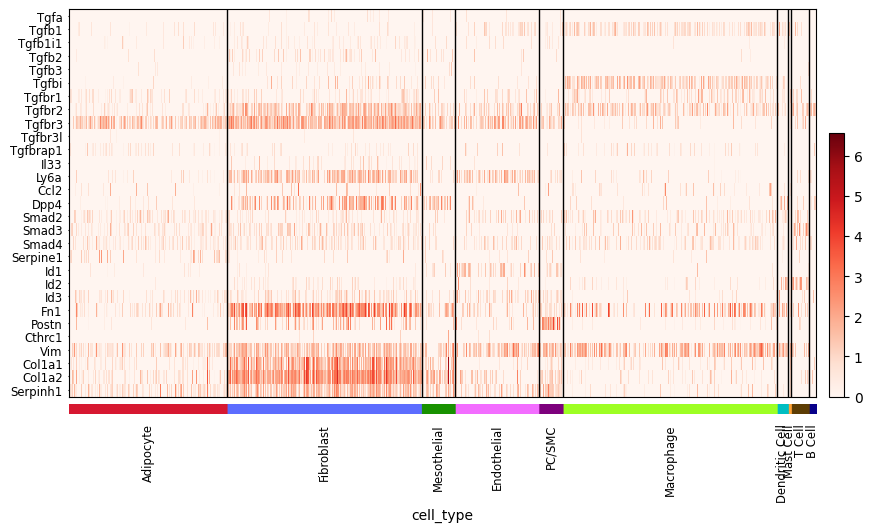

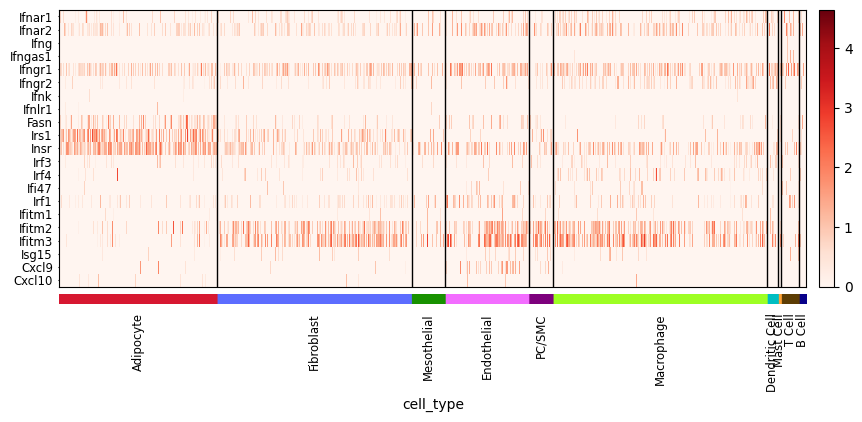

In [ ]:
sc.pl.heatmap(
    ewat_adata, tgfb_genes, "cell_type", layer="normalized", swap_axes=True, cmap="Reds"
)
sc.pl.heatmap(
    ewat_adata, ifn_genes, "cell_type", layer="normalized", swap_axes=True, cmap="Reds"
)

Text(0.5, 0.98, 'Cytokine-responsive genes in eWAT, by Condition')

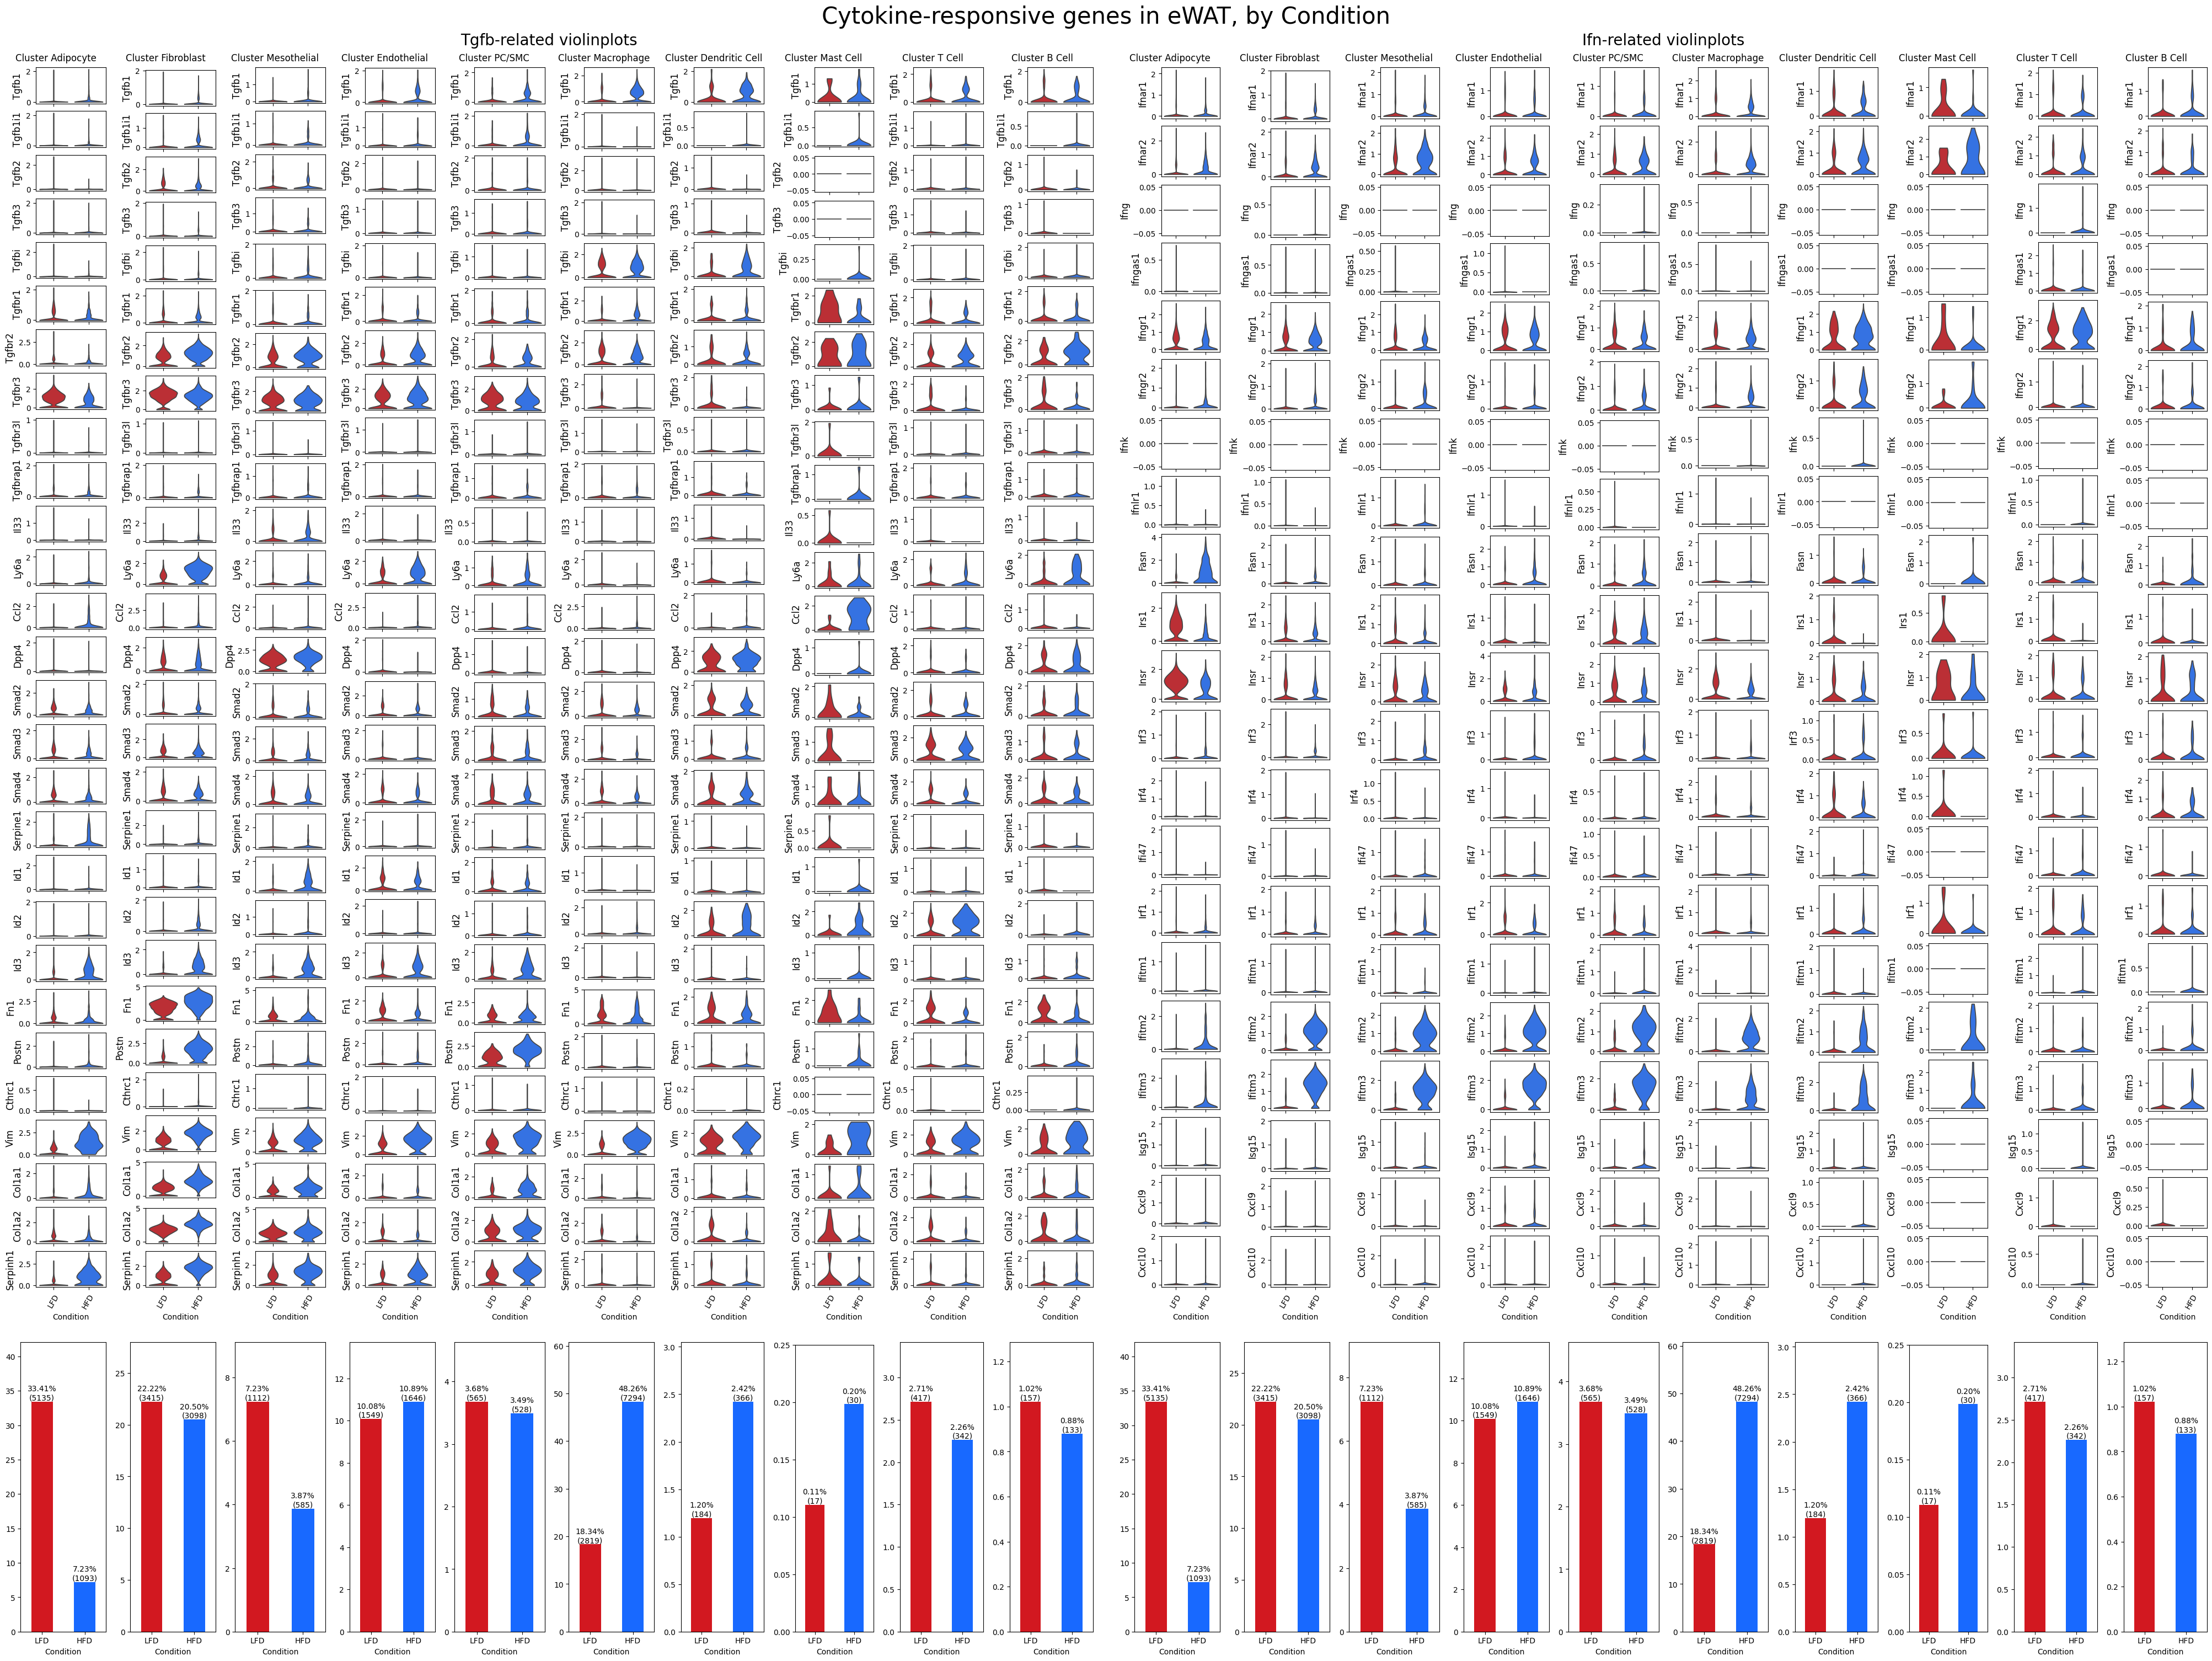

In [26]:
f = plt.figure(figsize=(40, 30), layout="constrained")
sf = f.subfigures(1, 2)

plot_cluster_violinplot(ewat_adata, "Condition", "cell_type", tgfb_genes, f=sf[0])
sf[0].suptitle("Tgfb-related violinplots", size=20)

plot_cluster_violinplot(ewat_adata, "Condition", "cell_type", ifn_genes, f=sf[1])
sf[1].suptitle("Ifn-related violinplots", size=20)

f.suptitle("Cytokine-responsive genes in eWAT, by Condition", size=30)

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<unknown>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2610450/3735222010.py:8: SyntaxWarning: invalid escape sequence '\d'


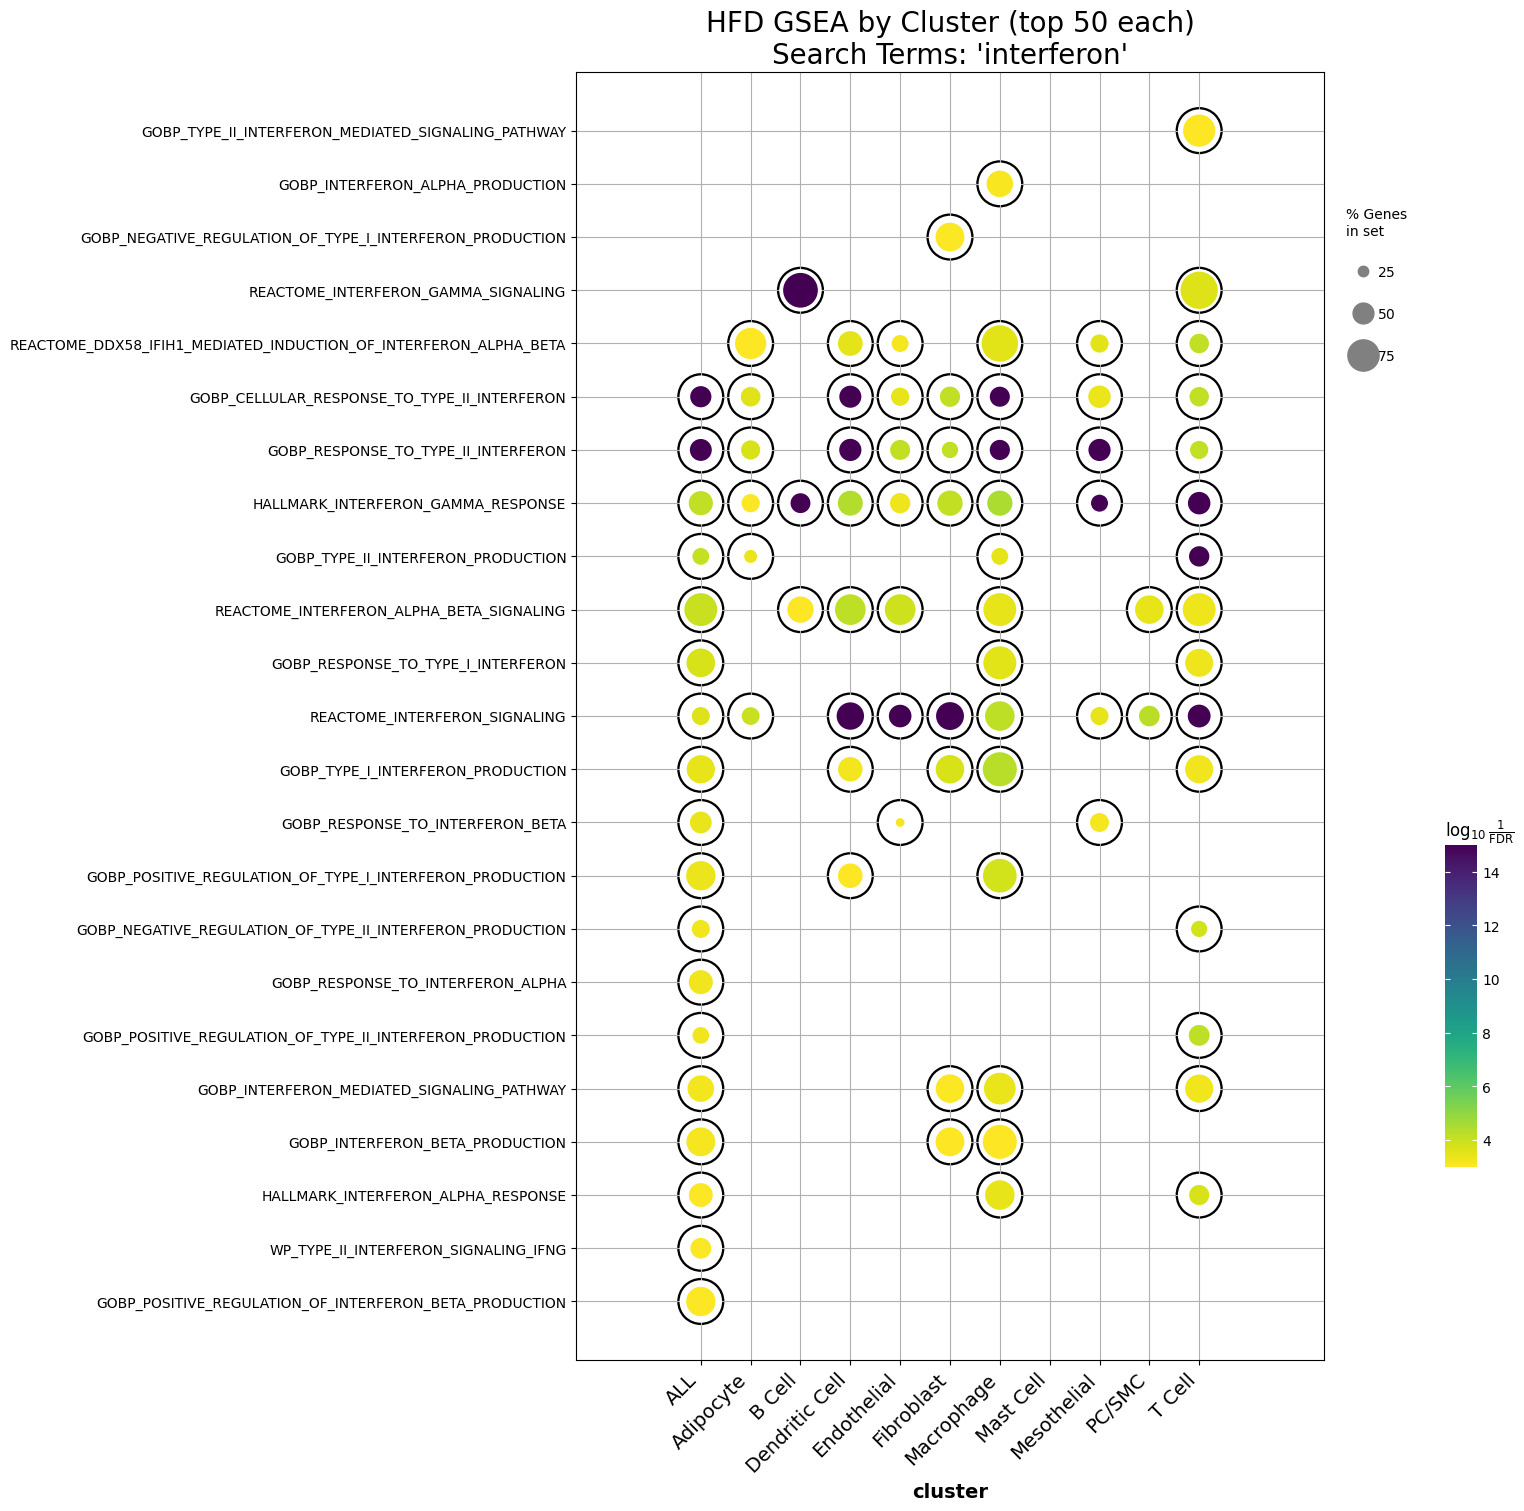

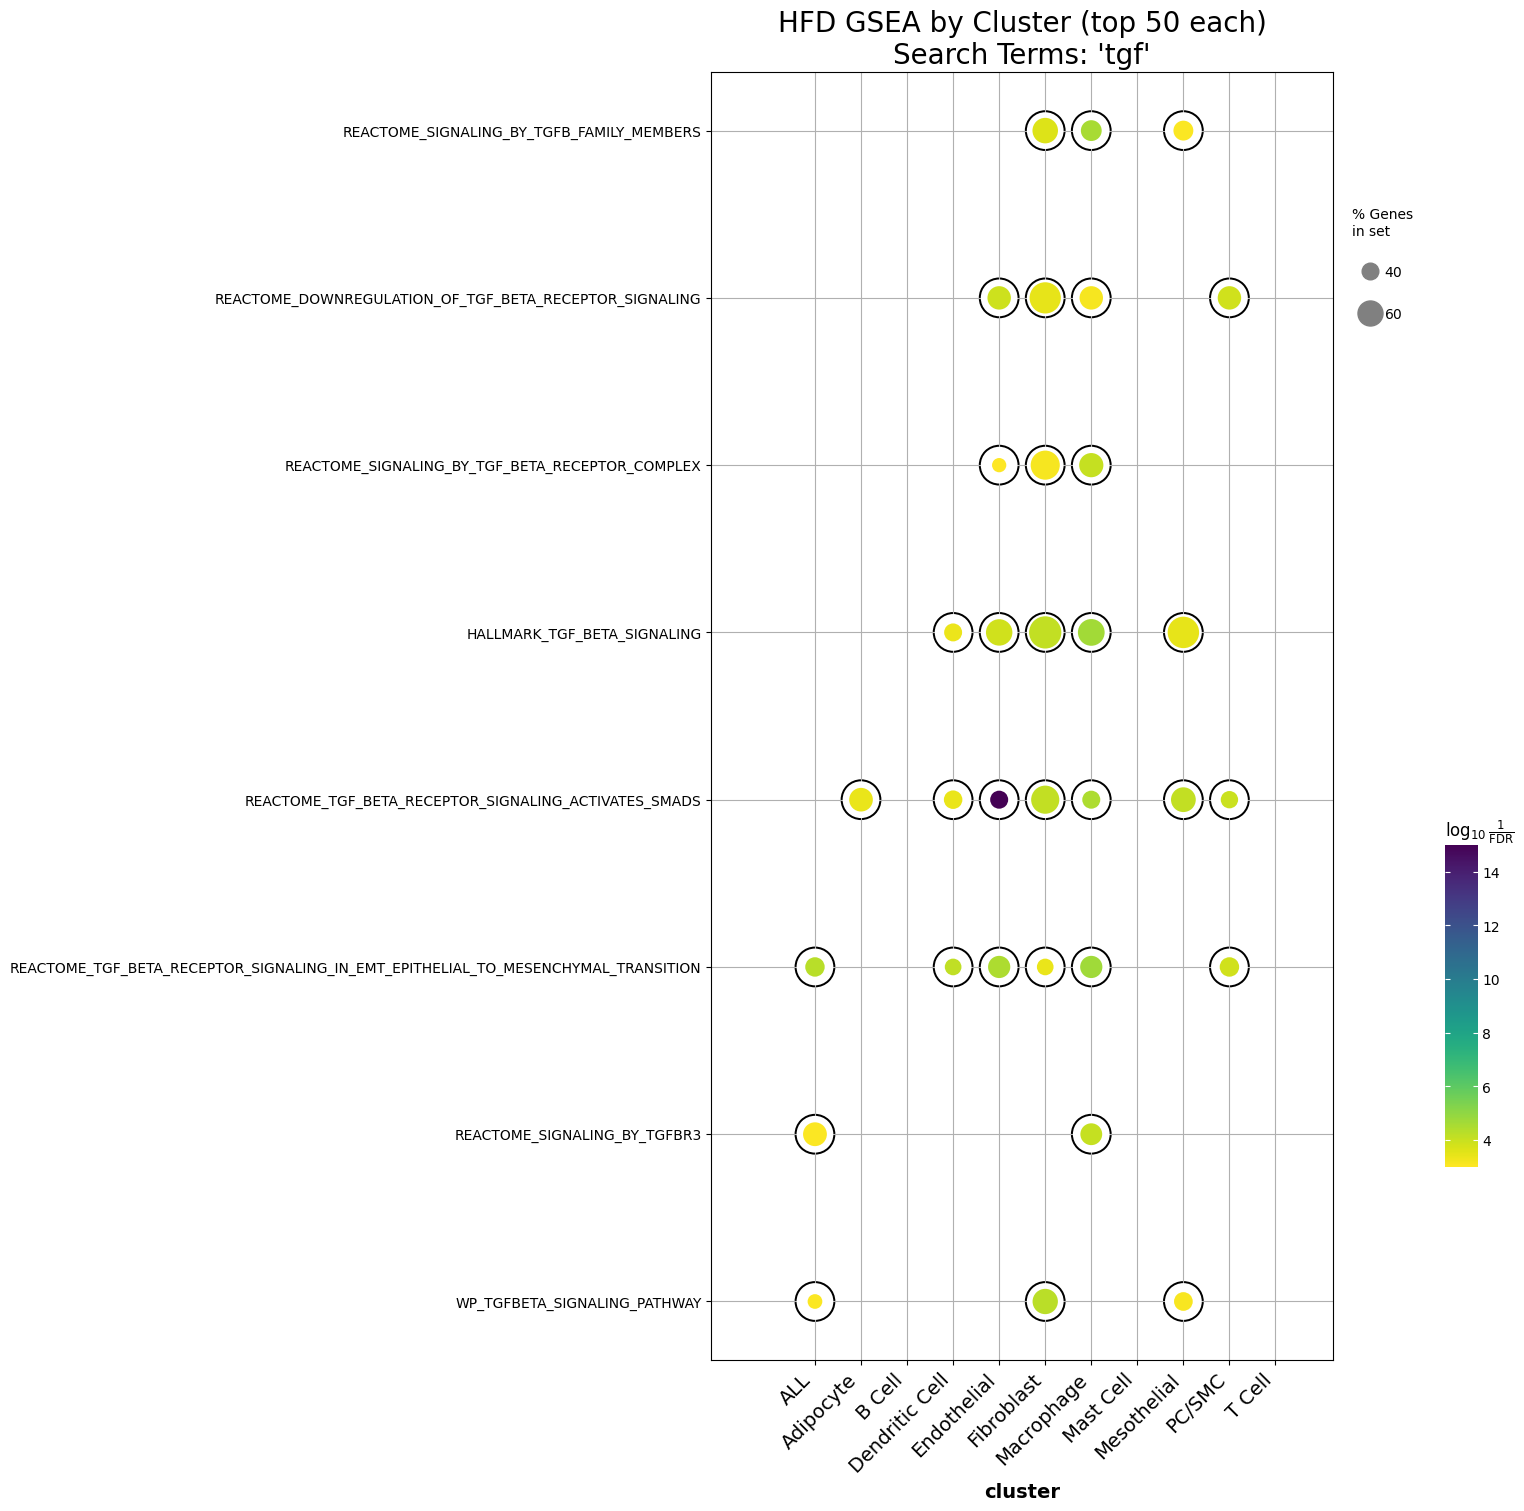

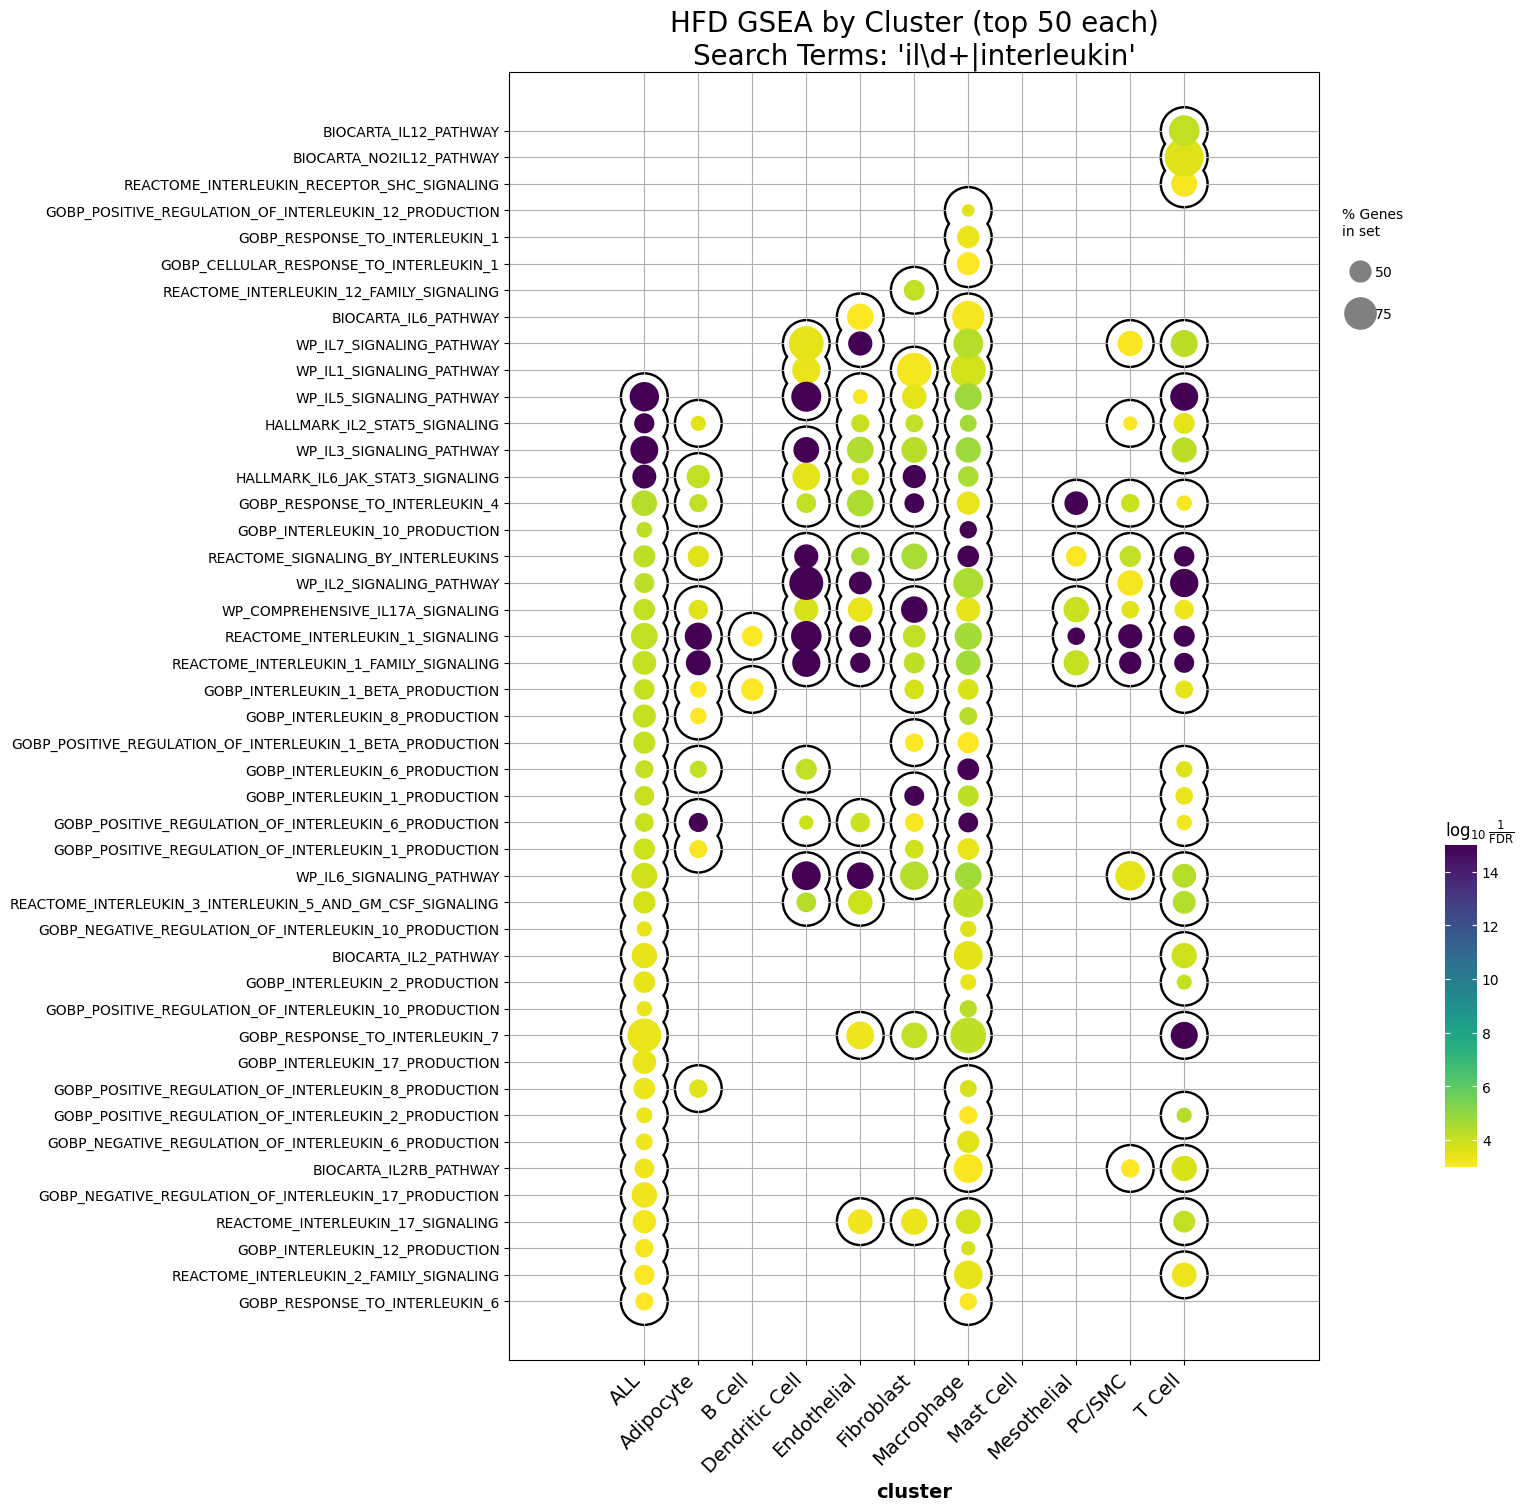

In [ ]:
# GSEApy approach, condition by cluster
runGSEA = False
method = "gsea"
cluster_key = "cell_type"
comparison = "Condition"

gs_queries = [[r"interferon", r"ifn"], [r"tgf", r"transforming.growth.factor"], [r"il\d+", r"interleukin"]]
# collection_query = ["mh"]
# gs_queries_exact = [
#     "HALLMARK_INTERFERON_GAMMA_RESPONSE",
#     "HALLMARK_INTERFERON_ALPHA_RESPONSE",
#     "HALLMARK_TGF_BETA_SIGNALING",
#     "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
# ]

top_n = 50
ncol = 3
nrow = 4
assert ncol * nrow >= len(ewat_adata.obs[comparison].cat.categories) + 1

annotation = "manDoublet-seuratV3-harmony-annotated - eWAT GSEA condition by celltype"
savedir = os.path.join(DATADIR, "processed", "single cell", "4_subclustered")


### PARAMETERS ABOVE

# get geneset info
ref_dir = os.path.join(REFDIR, "interactome")
gsea_sets = {
    "MACRO_MSigDB-MH": os.path.join(ref_dir, "mh.all.v2025.1.Mm.symbols.gmt"),
    "MACRO_MSigDB-M2-CP": os.path.join(ref_dir, "m2.cp.v2025.1.Mm.symbols.gmt"),
    # "MACRO_MSigDB-M3": os.path.join(ref_dir, "m3.all.v2025.1.Mm.symbols.gmt"),
    "MACRO_MSigDB-M5-GO": os.path.join(ref_dir, "m5.go.v2025.1.Mm.symbols.gmt"),
    # "MACRO_MSigDB-M7": os.path.join(ref_dir, "m7.all.v2025.1.Mm.symbols.gmt"),
    # "MACRO_MSigDB-M8": os.path.join(ref_dir, "m8.all.v2025.1.Mm.symbols.gmt"),
}

if runGSEA is True:
    cell_gsea_results = {}
    for cluster in ewat_adata.obs[cluster_key].unique():
        tmp = ewat_adata[ewat_adata.obs[cluster_key] == cluster]
        cell_gsea_results[cluster] = GSEA_gseapy(
            tmp,
            genesets=[dataset for dataset in gsea_sets.values()],
            method=method,
            groupby=comparison,
            permutation_num=500,
        )

    cell_gsea_results["ALL"] = GSEA_gseapy(
        ewat_adata,
        genesets=[dataset for dataset in gsea_sets.values()],
        method=method,
        groupby=comparison,
        permutation_num=500,
    )

    with open(os.path.join(savedir, f"{annotation}.pickle"), "wb") as handle:
        pickle.dump(cell_gsea_results, handle)
else:
    with open(os.path.join(savedir, f"{annotation}.pickle"), "rb") as handle:
        cell_gsea_results = pickle.load(handle)

collection_cols = color_gen(pd.Series(gsea_sets))

# f, ax = plt.subplots(nrow, ncol, figsize=(25 * ncol, 10 * nrow), layout="constrained")
# ax = ax.flatten()
# for n, cluster in enumerate(pd.Series(cell_gsea_results.keys()).sort_values()):
#     print(cluster)
#     tmp = cell_gsea_results[cluster]["HFD"].copy()
#     gp.plot.barplot(
#         tmp[tmp["FDR q-val"] < 0.25],
#         "NES",
#         group="Collection",
#         top_term=10,
#         ax=ax[n],
#         color=collection_cols,
#     )
#     ax[n].set_title(cluster, size=30)
# f.suptitle(f"GSEA enrichment for HFD by Cluster (top 10 each)", size=80)
# ax[-1].remove()

for queries in gs_queries:
    df_list = []
    for n, cluster in enumerate(pd.Series(cell_gsea_results.keys()).sort_values()):
        tmp = cell_gsea_results[cluster]["HFD"].copy()
        tmp["cluster"] = cluster
        # df_list.append(tmp[tmp.Collection.str.contains("|".join(queries), case=False, regex=True)])
        # df_list.append(tmp[tmp.Term.isin(gs_queries_exact)])
        df_list.append(
            tmp[tmp.Term.str.contains("|".join(queries), case=False, regex=True)]
        )

    results_grouped = pd.concat(df_list, axis=0)
    sort_cytokines_gsea(df_list, queries)

    f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
    gp.plot.dotplot(
        results_grouped,
        "FDR q-val",
        x="cluster",
        ax=ax,
        top_term=top_n,
        cutoff=1e-3,
        xticklabels_rot=45,
        show_ring=True,
        x_order=["ALL"]
        + ewat_adata.obs[cluster_key].cat.categories.sort_values().to_list(),
    )
    plt.title(
        f"HFD GSEA by Cluster (top {top_n} each)\nSearch Terms: '{"|".join(queries)}'",
        size=20,
    )
    plt.yticks(fontsize=10)
    plt.grid(axis="x")

## FB only

In [7]:
# load
fibro_adata = adata[adata.obs["cell_type"] == "Fibroblast"]

ewat_fibro = fibro_adata[fibro_adata.obs["Sample Type"] == "eWAT"]
hfd_ewat_fibro = ewat_fibro[ewat_fibro.obs["Condition"] == "HFD"]
lfd_ewat_fibro = ewat_fibro[ewat_fibro.obs["Condition"] == "LFD"]

Text(0.5, 0.98, 'Cytokine-Responsive Genes in eWAT FB subsets')

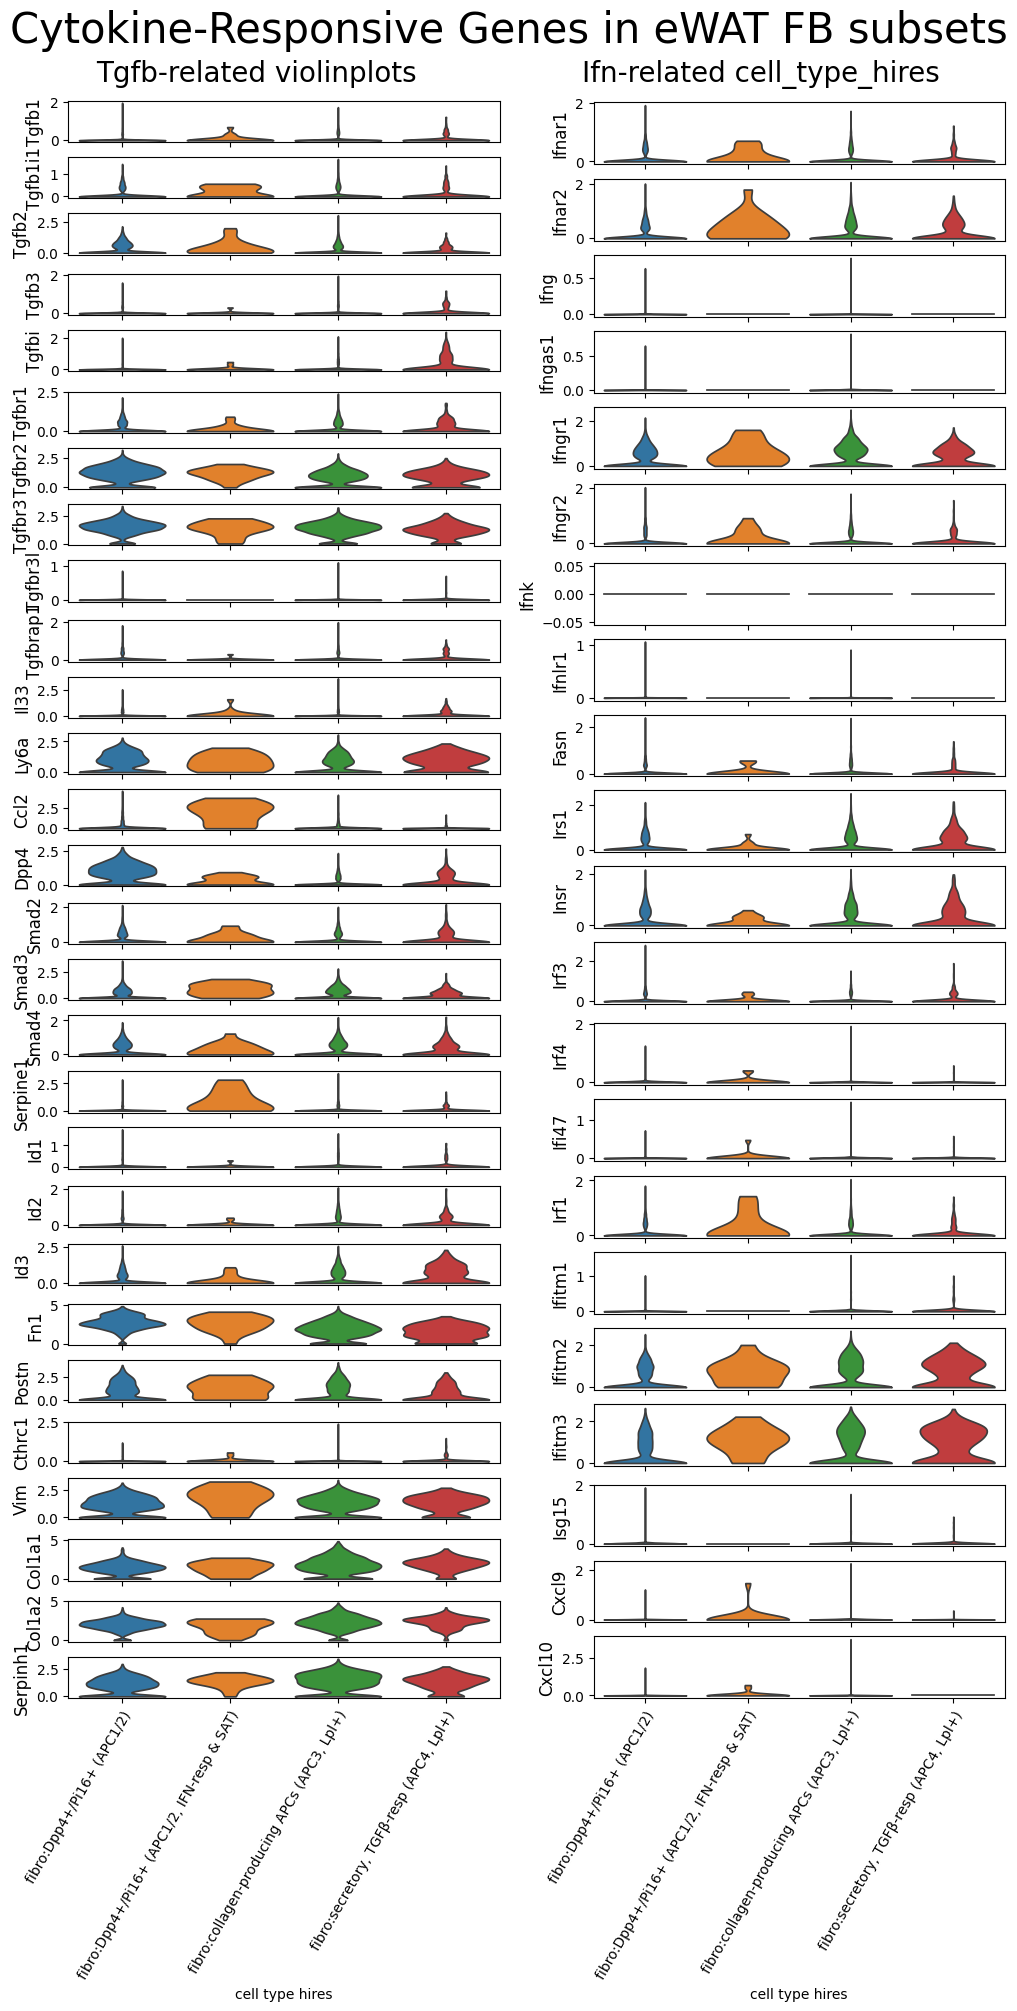

In [ ]:
f = plt.figure(figsize=(10, 25), layout="constrained")
sf = f.subfigures(1, 2)
plot_violinplot(ewat_fibro, tgfb_genes, "cell_type_hires", f=sf[0], useStripPlot=False)
sf[0].suptitle("Tgfb-related violinplots", size=20)

plot_violinplot(ewat_fibro, ifn_genes, "cell_type_hires", f=sf[1], useStripPlot=False)
sf[1].suptitle("Ifn-related cell_type_hires", size=20)

f.suptitle("Cytokine-Responsive Genes in eWAT FB subsets", size=30)

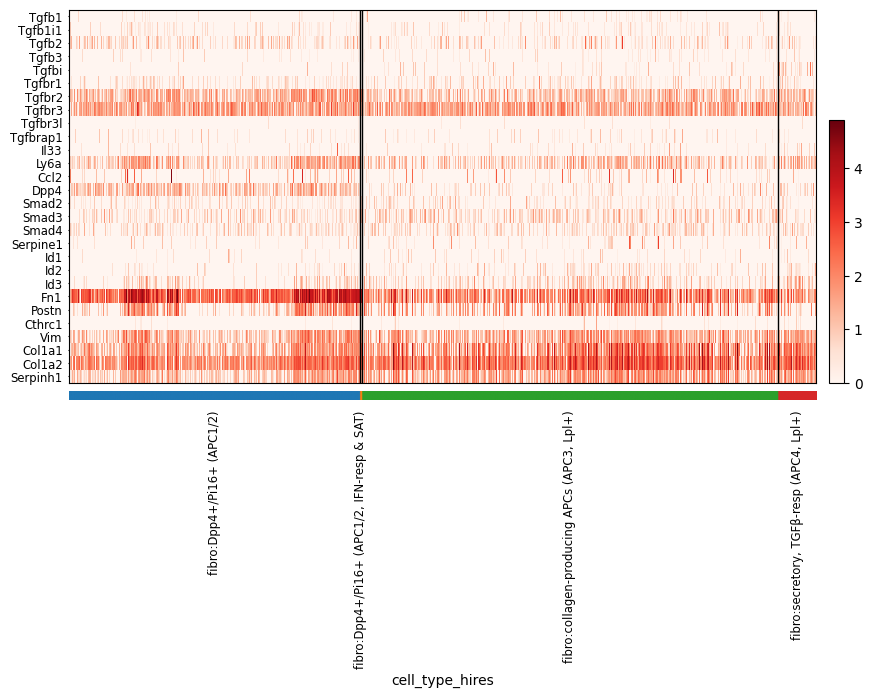

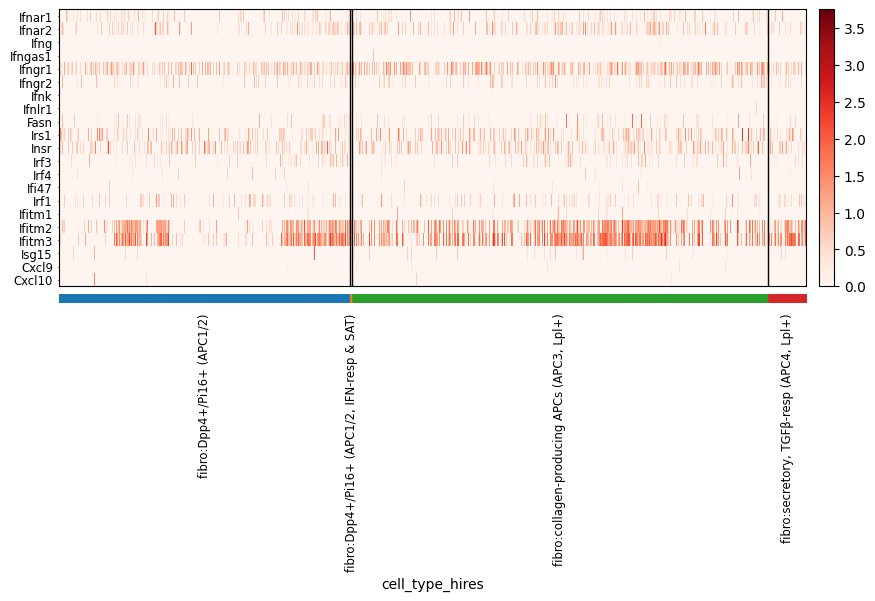

In [10]:
sc.pl.heatmap(
    ewat_fibro,
    tgfb_genes,
    "cell_type_hires",
    layer="normalized",
    swap_axes=True,
    cmap="Reds",
)
sc.pl.heatmap(
    ewat_fibro,
    ifn_genes,
    "cell_type_hires",
    layer="normalized",
    swap_axes=True,
    cmap="Reds",
)

Text(0.5, 0.98, 'Cytokine-responsive genes in eWAT FB subsets, by Condition')

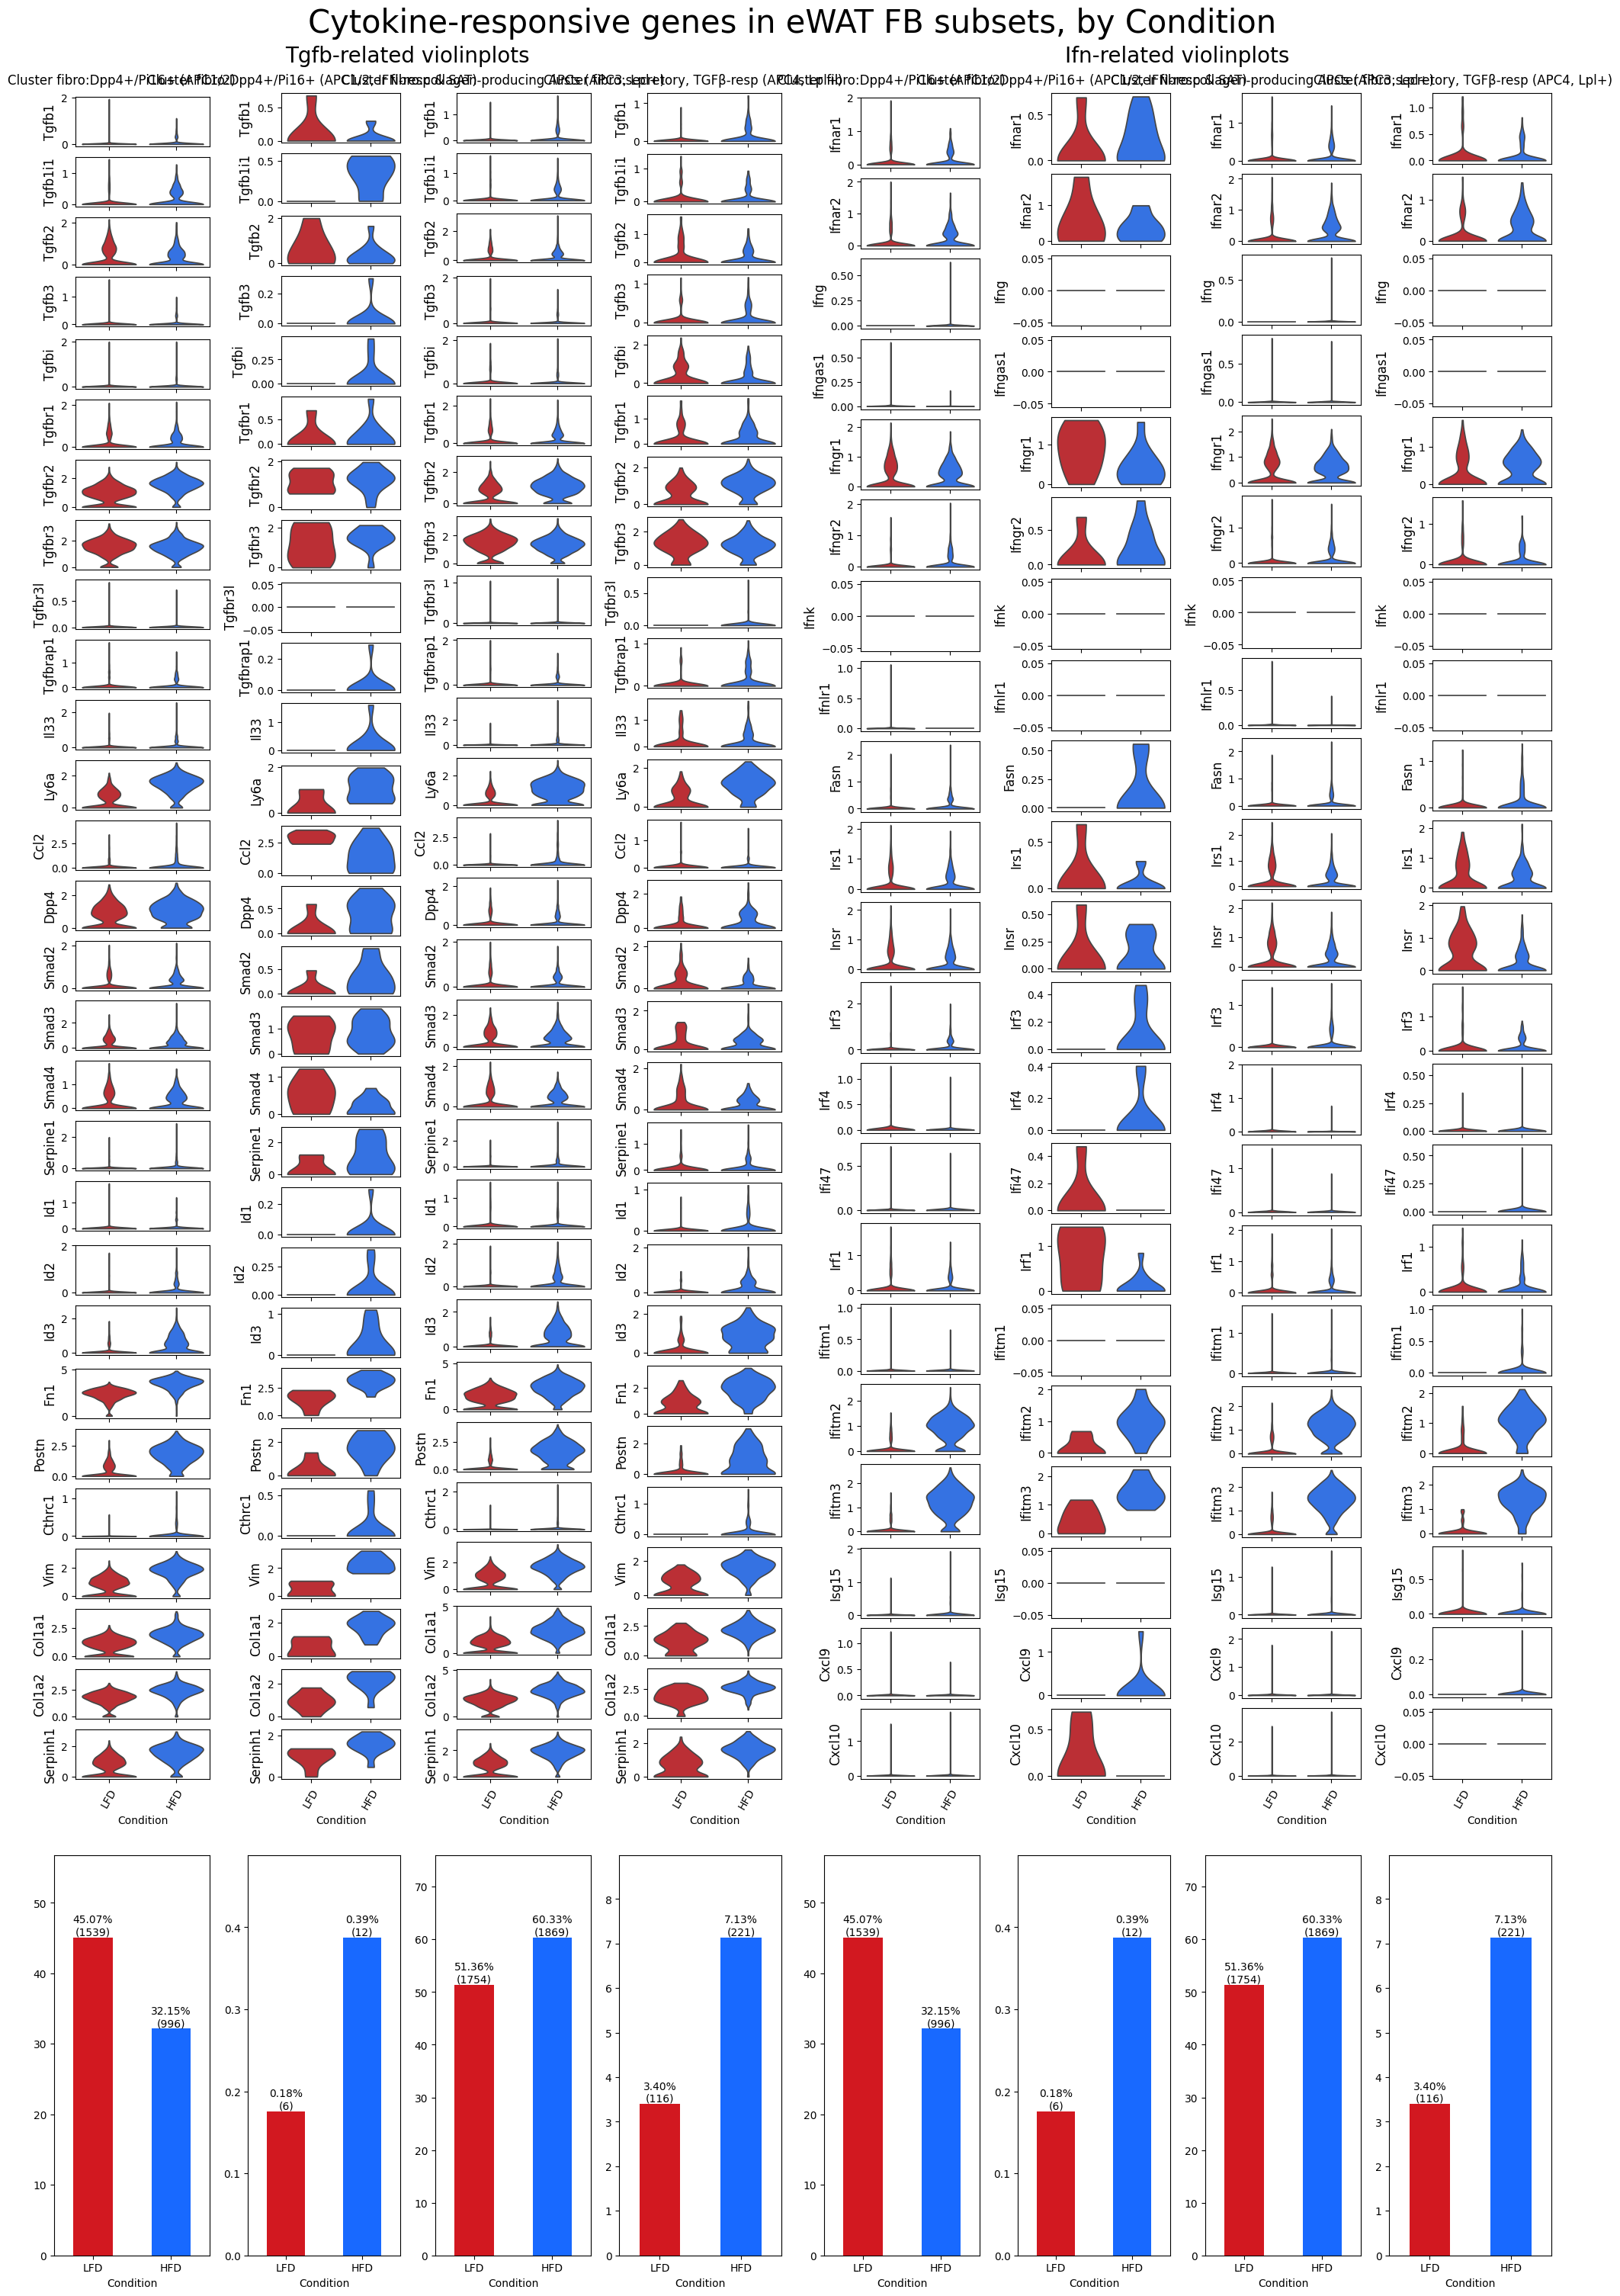

In [15]:
f = plt.figure(figsize=(20, 30), layout="constrained")
sf = f.subfigures(1, 2)

plot_cluster_violinplot(ewat_fibro, "Condition", "cell_type_hires", tgfb_genes, f=sf[0])
sf[0].suptitle("Tgfb-related violinplots", size=20)

plot_cluster_violinplot(ewat_fibro, "Condition", "cell_type_hires", ifn_genes, f=sf[1])
sf[1].suptitle("Ifn-related violinplots", size=20)

f.suptitle("Cytokine-responsive genes in eWAT FB subsets, by Condition", size=30)

In [ ]:
# GSEApy approach, condition by cluster
runGSEA = True
method = "gsea"
cluster_key = "cell_type"
comparison = "Condition"

gs_queries = [
    [r"interferon", r"ifn"],
    [r"tgf", r"transforming.growth.factor"],
    [r"il\d+", r"interleukin"],
]
# gs_queries_exact = [
#     "HALLMARK_INTERFERON_GAMMA_RESPONSE",
#     "HALLMARK_INTERFERON_ALPHA_RESPONSE",
#     "HALLMARK_TGF_BETA_SIGNALING",
#     "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
# ]
# collection_query = ["mh"]

top_n = 50
ncol = 2
nrow = 3
assert ncol * nrow >= len(ewat_fibro.obs[comparison].cat.categories) + 1

annotation = "POSTER manDoublet-seuratV3-harmony-annotated-fibro - eWAT GSEA condition by cluster"
savedir = os.path.join(DATADIR, "processed", "single cell", "4_subclustered")


### PARAMETERS ABOVE

# get geneset info
ref_dir = os.path.join(REFDIR, "interactome")
gsea_sets = {
    "MACRO_MSigDB-MH": os.path.join(ref_dir, "mh.all.v2025.1.Mm.symbols.gmt"),
    "MACRO_MSigDB-M2-CP": os.path.join(ref_dir, "m2.cp.v2025.1.Mm.symbols.gmt"),
    # "MACRO_MSigDB-M3": os.path.join(ref_dir, "m3.all.v2025.1.Mm.symbols.gmt"),
    "MACRO_MSigDB-M5-GO": os.path.join(ref_dir, "m5.go.v2025.1.Mm.symbols.gmt"),
    # "MACRO_MSigDB-M7": os.path.join(ref_dir, "m7.all.v2025.1.Mm.symbols.gmt"),
    # "MACRO_MSigDB-M8": os.path.join(ref_dir, "m8.all.v2025.1.Mm.symbols.gmt"),
}

if runGSEA is True:
    cell_gsea_results = {}
    for cluster in ewat_fibro.obs[cluster_key].unique():
        tmp = ewat_fibro[ewat_fibro.obs[cluster_key] == cluster]
        cell_gsea_results[cluster] = GSEA_gseapy(
            tmp,
            genesets=[dataset for dataset in gsea_sets.values()],
            method=method,
            groupby=comparison,
            permutation_num=500,
        )

    cell_gsea_results["ALL"] = GSEA_gseapy(
        ewat_fibro,
        genesets=[dataset for dataset in gsea_sets.values()],
        method=method,
        groupby=comparison,
        permutation_num=500,
    )

    with open(os.path.join(savedir, f"{annotation}.pickle"), "wb") as handle:
        pickle.dump(cell_gsea_results, handle)
else:
    with open(os.path.join(savedir, f"{annotation}.pickle"), "rb") as handle:
        cell_gsea_results = pickle.load(handle)

collection_cols = color_gen(pd.Series(gsea_sets))

# f, ax = plt.subplots(nrow, ncol, figsize=(25 * ncol, 10 * nrow), layout="constrained")
# ax = ax.flatten()
# for n, cluster in enumerate(pd.Series(cell_gsea_results.keys()).sort_values()):
#     print(cluster)
#     tmp = cell_gsea_results[cluster]["HFD"].copy()
#     gp.plot.barplot(
#         tmp[tmp["FDR q-val"] < 0.25],
#         "NES",
#         group="Collection",
#         top_term=10,
#         ax=ax[n],
#         color=collection_cols,
#     )
#     ax[n].set_title(cluster, size=30)
# f.suptitle(f"GSEA enrichment for HFD by Cluster (top 10 each)", size=80)
# ax[-1].remove()

for queries in gs_queries:
    df_list = []
    for n, cluster in enumerate(pd.Series(cell_gsea_results.keys()).sort_values()):
        tmp = cell_gsea_results[cluster]["HFD"].copy()
        tmp["cluster"] = cluster
        # df_list.append(tmp[tmp.Collection.str.contains("|".join(queries), case=False, regex=True)])
        # df_list.append(tmp[tmp.Term.isin(gs_queries_exact)])
        df_list.append(
            tmp[tmp.Term.str.contains("|".join(queries), case=False, regex=True)]
        )

    results_grouped = pd.concat(df_list, axis=0)
    sort_cytokines_gsea(df_list, queries)

    f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
    gp.plot.dotplot(
        results_grouped,
        "FDR q-val",
        x="cluster",
        ax=ax,
        top_term=top_n,
        cutoff=1e-3,
        xticklabels_rot=45,
        show_ring=True,
        x_order=["ALL"]
        + ewat_fibro.obs[cluster_key].cat.categories.sort_values().to_list(),
    )
    plt.title(
        f"HFD GSEA by Cluster (top {top_n} each)\nSearch Terms: '{"|".join(queries)}'",
        size=20,
    )
    plt.yticks(fontsize=10)
    plt.grid(axis="x")

  0%|          | 0/2 [00:00<?, ?it/s]